In [47]:
from src.main.controller.CLDNNController import CLDNNController
from pathlib import Path

%load_ext autoreload
%autoreload 2

ROOT = Path.cwd().resolve().parent.parent.parent
path_dataset = ROOT / "dataset" / "cv-corpus-mozilla-pt" / "data"
path_model_checkpoint = ROOT / "src" / "config" / "modelCheckpoint" / "CLDNN" / "flow-matching-checkpoint-50000steps.pkl"
path_model_params = None # ROOT / "src" / "config" / "yaml" / "cldnn_vc.mel.v1.yaml"
epochs = 5
list_mods = ["flow_matching"]
is_test = False

name_experiment = "cldnn-mod"
mod_name = ""
for mod in list_mods:
    mod_name = mod_name +"-"+mod
name_experiment += mod_name


controller = CLDNNController(
    batch_size=2,
    path_dataset=path_dataset,
    path_checkpoint=path_model_checkpoint,
    path_model_params=path_model_params
)
controller.set_mod(list_mods,device="cpu")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\USER\_netrc


HiFi-GAN: Removing weight norm.


In [48]:
mels = controller.inference(8,1, device="cpu")

In [50]:
audio_pred, mel_pred, mel_orig, mel_noise = mels
mel_orig = mel_orig.transpose(1,2).detach()
mel_noise = mel_noise.transpose(1,2).detach()
print(audio_pred.shape)
print(mel_pred.shape)
print(mel_orig.shape)
print(mel_noise.shape)

torch.Size([1, 1, 82688])
torch.Size([1, 80, 323])
torch.Size([1, 80, 323])
torch.Size([1, 80, 323])


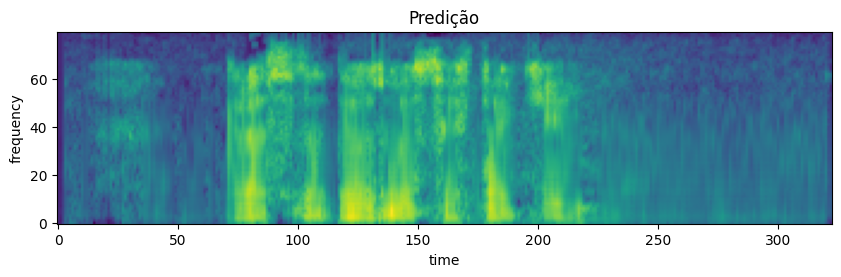

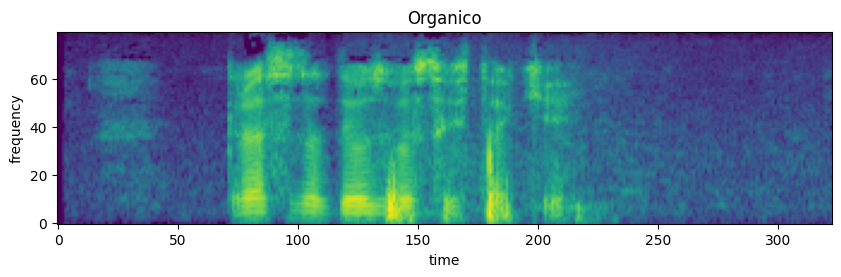

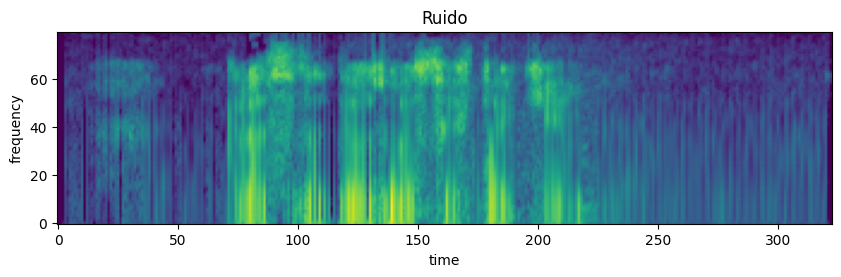

In [51]:
from src.common.utils.visualizar import vizualizar_spectrogram
%matplotlib inline

vizualizar_spectrogram(mel_pred[0], "Predição")
vizualizar_spectrogram(mel_orig[0],"Organico")
vizualizar_spectrogram(mel_noise[0],"Ruido")

In [34]:
from IPython.lib.display import Audio

audio_pred = audio_pred[0].cpu().detach().numpy()
Audio(audio_pred, rate=22050)

In [42]:
import matplotlib.pyplot as plt

epocas = [1, 2, 3, 4, 5]

dados = {
    "MSD": [
        0.08635084321572271,
        0.08861196412383389,
        0.08806362266915561,
        0.08575813936349377,
        0.08507242228854905
    ],

    "MDC": [
        28.667180699668716,
        28.260617428963158,
        27.892177233493236,
        27.96298221617089,
        26.48754856875468
    ],

    "F0_RMSE_LOG": [
        0.5995703425917229,
        0.597507988791495,
        0.6024359316635096,
        0.6037707721488111,
        0.6176210245478055
    ],

    "F0_RMSE": [
        23.229721682509524,
        23.10861504207909,
        23.428302782920387,
        23.55598039926959,
        24.540569028308852
    ],

    "PSNR": [
        49.74871053437249,
        50.08882736615338,
        50.22332841018473,
        50.1611804916043,
        50.57705982749861
    ],

    "SNR": [
        9.59447193145752,
        9.821447372436523,
        9.949207305908203,
        9.960923194885254,
        10.3134
    ],

    "Loss Val": [
        0.7980541197510165,
        0.7260624609604779,
        0.7055999494952062,
        0.7003476740339437,
        0.5523767440214152
    ],

    "Loss Train": [
        4.805948850567185e-05,
        7.397163034133585e-05,
        0.00011025233652765295,
        0.00012712439187210513,
        4.589056050906594e-05
    ]
}

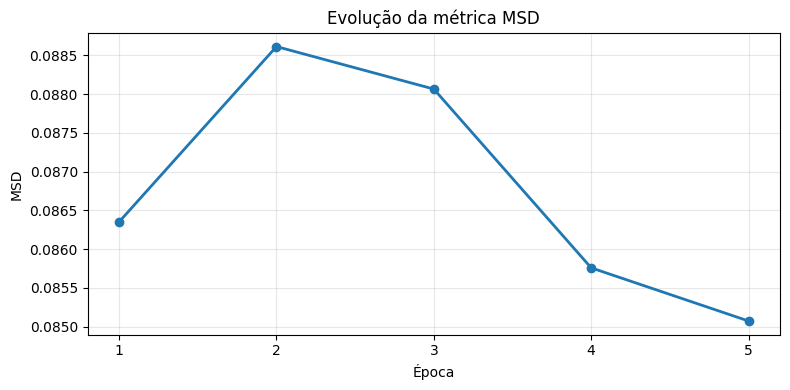

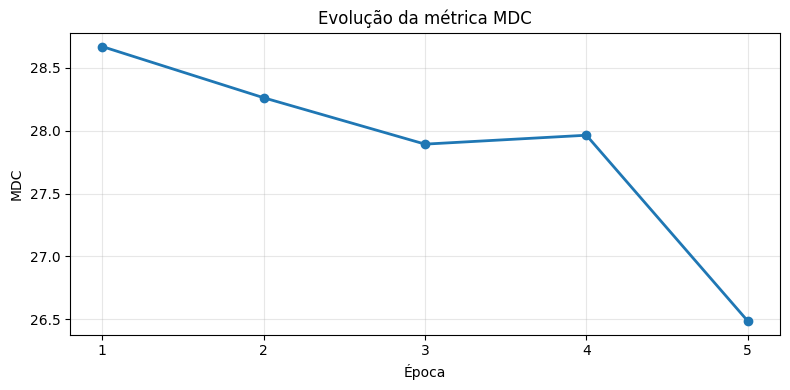

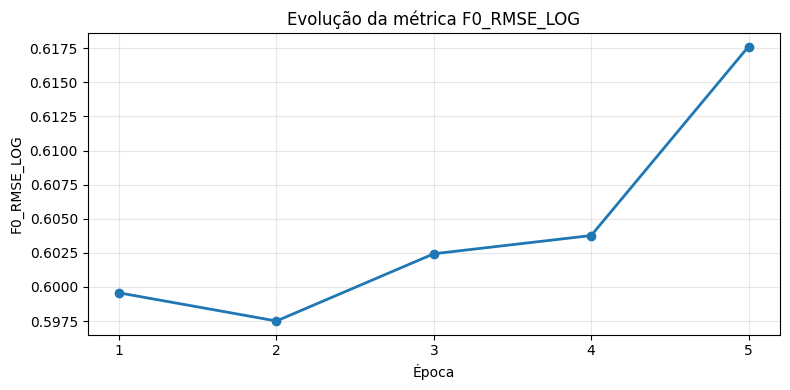

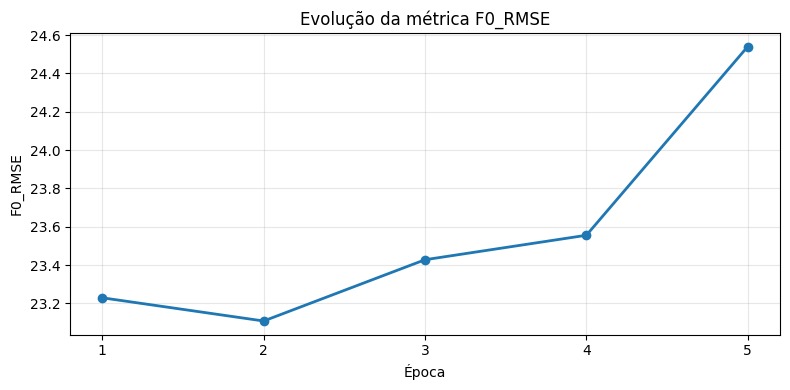

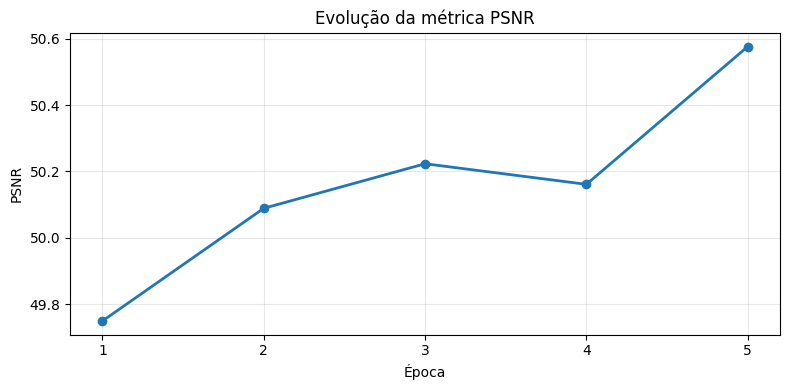

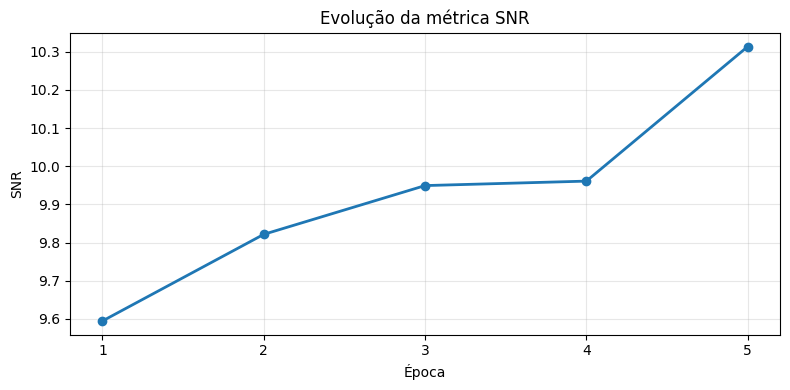

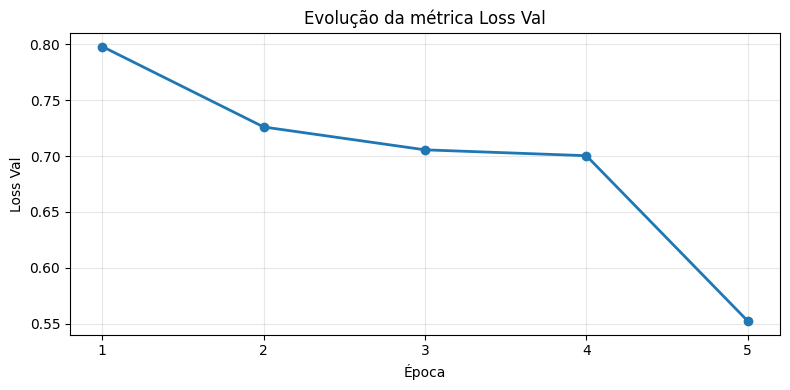

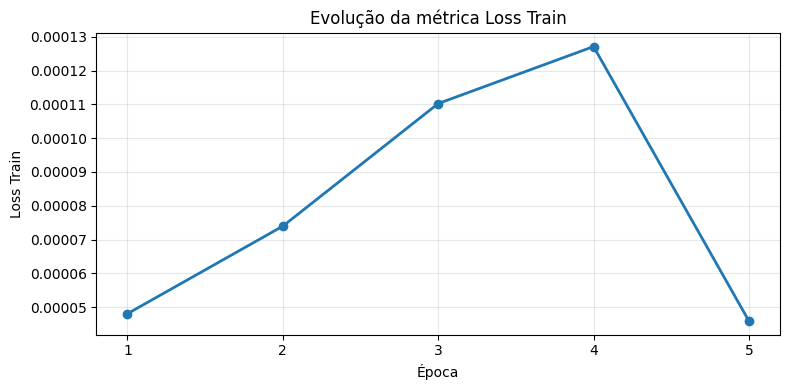

In [43]:
for nome, valores in dados.items():

    plt.figure(figsize=(8, 4))

    plt.plot(
        epocas,
        valores,
        marker="o",
        linewidth=2
    )

    plt.title(f"Evolução da métrica {nome}")
    plt.xlabel("Época")
    plt.ylabel(nome)

    plt.xticks(epocas)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()